In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [15]:
# 1. LOAD DATA
def load_data():

    estimation = pd.read_csv("../../data/processed/estimation_window.csv")
    events = pd.read_csv("../../data/processed/events_window.csv")
    market = pd.read_csv("../../data/raw/market_data.csv")

    estimation["date"] = pd.to_datetime(estimation["date"])
    events["date"] = pd.to_datetime(events["date"])
    market["date"] = pd.to_datetime(market["Date"])

    return estimation, events, market

In [16]:
# 2. MARKET MODEL PARAMETER ESTIMATION
def estimate_parameters(estimation):

    params = []

    for event_id, group in estimation.groupby("event_id"):

        alpha = group["sp500_log_return"].mean()

        params.append({
            "event_id": event_id,
            "alpha": alpha
        })

    return pd.DataFrame(params)


In [17]:
# 3. ABNORMAL RETURNS
def compute_abnormal_returns(events, params):

    events = events.merge(params, on="event_id", how="left")

    events["expected_return"] = events["alpha"]

    events["abnormal_return"] = (
        events["sp500_log_return"] -
        events["expected_return"]
    )

    events = events.sort_values(["event_id","t"])

    events["CAR"] = (
        events
        .groupby("event_id")["abnormal_return"]
        .cumsum()
    )

    return events


In [18]:
# 4. CAR WINDOWS
def compute_car_windows(events):

    car_3 = (
        events[events["t"] <= 3]
        .groupby("event_id")["abnormal_return"]
        .sum()
        .reset_index(name="CAR_0_3")
    )

    car_10 = (
        events[events["t"] <= 10]
        .groupby("event_id")["abnormal_return"]
        .sum()
        .reset_index(name="CAR_0_10")
    )

    car_30 = (
        events[events["t"] <= 30]
        .groupby("event_id")["abnormal_return"]
        .sum()
        .reset_index(name="CAR_0_30")
    )

    car = car_3.merge(car_10, on="event_id")
    car = car.merge(car_30, on="event_id")

    return car



In [19]:
# 5. VIX VOLATILITY
def compute_vix_volatility(estimation, events):

    baseline_vix = (
        estimation
        .groupby("event_id")["vix"]
        .mean()
        .reset_index(name="vix_baseline")
    )

    event_vix = (
        events[events["t"] <= 3]
        .groupby("event_id")["vix"]
        .mean()
        .reset_index(name="vix_event")
    )

    vix = baseline_vix.merge(event_vix, on="event_id")

    vix["excess_vix"] = (
        vix["vix_event"] -
        vix["vix_baseline"]
    )

    return vix


In [20]:
# 6. REALIZED VOLATILITY
def compute_realized_volatility(market, events):

    market["rv20"] = (
        market["sp500_log_return"]
        .rolling(20)
        .std()
    )

    events = events.merge(
        market[["date","rv20"]],
        on="date",
        how="left"
    )

    rv_event = (
        events[events["t"] <= 20]
        .groupby("event_id")["rv20"]
        .mean()
        .reset_index(name="rv_event")
    )

    rv_baseline = (
        events[(events["t"] >= -65) & (events["t"] <= -20)]
        .groupby("event_id")["rv20"]
        .mean()
        .reset_index(name="rv_baseline")
    )

    rv = rv_event.merge(rv_baseline, on="event_id")

    rv["excess_rv"] = (
        rv["rv_event"] -
        rv["rv_baseline"]
    )

    return rv


In [21]:
# 7. AAR AND CAAR
def compute_aar_caar(events):

    aar = (
        events
        .groupby("t")["abnormal_return"]
        .mean()
        .reset_index()
    )

    aar.rename(columns={"abnormal_return":"AAR"}, inplace=True)

    aar["CAAR"] = aar["AAR"].cumsum()

    return aar


In [22]:
# 8. SIGNIFICANCE TEST
def t_test(events):

    results = []

    for t in events["t"].unique():

        sample = events[events["t"] == t]["abnormal_return"]

        t_stat, p_val = stats.ttest_1samp(sample,0)

        results.append({
            "t":t,
            "t_stat":t_stat,
            "p_value":p_val
        })

    return pd.DataFrame(results)


In [23]:
# 9. BOOTSTRAP CONFIDENCE INTERVAL
def bootstrap_ci(events, n_bootstrap=1000):

    results = []

    for t in events["t"].unique():

        sample = events[events["t"]==t]["abnormal_return"].values

        boot_means=[]

        for _ in range(n_bootstrap):

            resample=np.random.choice(sample,len(sample),replace=True)

            boot_means.append(np.mean(resample))

        lower=np.percentile(boot_means,2.5)
        upper=np.percentile(boot_means,97.5)

        results.append({
            "t":t,
            "ci_lower":lower,
            "ci_upper":upper
        })

    return pd.DataFrame(results)


In [24]:
# 10. CAAR PLOT (-10 → 30)
def plot_caar(events):

    events = events[(events["t"]>=-10) & (events["t"]<=30)]

    aar = compute_aar_caar(events)

    plt.figure(figsize=(10,6))

    plt.plot(aar["t"],aar["CAAR"])

    plt.axvline(0)
    plt.axhline(0)

    plt.title("Cumulative Average Abnormal Return")
    plt.xlabel("Event Time (Days)")
    plt.ylabel("CAAR")

    plt.savefig("../../outputs/caar_plot.png",dpi=300)

    plt.show()


In [25]:
# 11. REGRESSION
def run_regression(dataset):

    X = dataset[[
        "sentiment_score",
        "excess_vix",
        "treasury_10y",
        "treasury_2y"
    ]]

    X = sm.add_constant(X)

    y = dataset["CAR_0_3"]

    model = sm.OLS(y,X).fit()

    print(model.summary())

    return model


In [26]:
# 12. MAIN PIPELINE
# def run_event_study():

print("Loading data")
estimation, events, market = load_data()

print("Estimating parameters")
params = estimate_parameters(estimation)



Loading data
Estimating parameters


In [27]:
print("Computing abnormal returns")
events = compute_abnormal_returns(events,params)

print("Computing CAR windows")
car = compute_car_windows(events)



Computing abnormal returns
Computing CAR windows


In [28]:
print("Computing volatility metrics")
vix = compute_vix_volatility(estimation,events)
rv = compute_realized_volatility(market,events)

print("Computing AAR/CAAR")
aar = compute_aar_caar(events)



Computing volatility metrics
Computing AAR/CAAR


Running statistical tests
Plotting CAAR


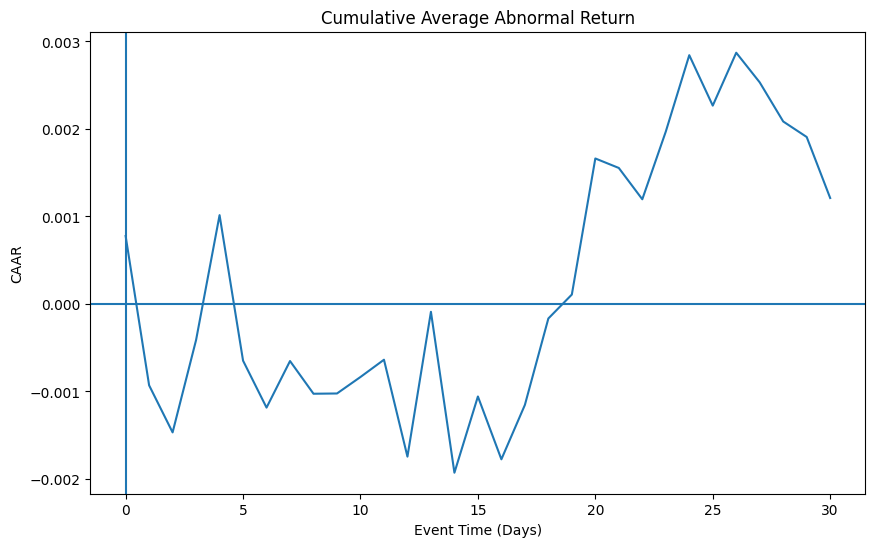

In [29]:
print("Running statistical tests")
ttest = t_test(events)
ci = bootstrap_ci(events)

print("Plotting CAAR")
plot_caar(events)



In [ ]:
print("Saving outputs")

aar.to_csv("../../data/processed/aar_caar.csv",index=False)
ttest.to_csv("../../data/processed/ttest_results.csv",index=False)
ci.to_csv("../../data/processed/bootstrap_ci.csv",index=False)

results = car.merge(vix,on="event_id")
results = results.merge(rv,on="event_id")

results.to_csv("../../data/processed/event_study_results.csv",index=False)

print("Event study completed")

Saving outputs
Event study completed
